In [1]:
# Install required libraries
!pip install -q opencv-python-headless scikit-learn seaborn matplotlib kagglehub

import os
import sys
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import kagglehub

# ----- Seed & Device Setup -----
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----- Hyperparameters & Paths -----
IMG_SIZE = 224
BATCH_SIZE = 32
ARCHITECTURE = "resnet50"

HEAD_EPOCHS = 4
FULL_EPOCHS = 12

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Dataset Resolution
KAGGLE_INPUT_DIR = "/kaggle/input/brain-tumor-mri-dataset"
if os.path.exists(KAGGLE_INPUT_DIR):
    DATA_DIR = KAGGLE_INPUT_DIR
else:
    DATA_DIR = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

train_dir = os.path.join(DATA_DIR, "Training")
test_dir = os.path.join(DATA_DIR, "Testing")
class_names = sorted(os.listdir(train_dir))
print("Classes found:", class_names)

# ----- Advanced MRI Augmentations -----
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets & Split
full_train_dataset = ImageFolder(train_dir, transform=train_transform)
test_dataset = ImageFolder(test_dir, transform=eval_transform)

targets = full_train_dataset.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.15, random_state=42, stratify=targets
)

train_dataset = Subset(full_train_dataset, train_idx)
val_dataset_base = ImageFolder(train_dir, transform=eval_transform)
val_dataset = Subset(val_dataset_base, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ----- Focal Loss Implementation -----
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class_counts = np.bincount([targets[i] for i in train_idx])
total_samples = len(train_idx)
class_weights = total_samples / (len(class_names) * class_counts)

if "notumor" in class_names:
    notumor_idx = class_names.index("notumor")
    class_weights[notumor_idx] *= 0.4  # Penalize 'notumor' false negatives heavily

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)

# ----- Model Setup -----
def build_model(num_classes=4):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model(len(class_names)).to(device)

# Phase 1: Train Head Only
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer_head = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

print("--- Phase 1: Training Classification Head ---")
for epoch in range(HEAD_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_head.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_head.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    print(f"Epoch {epoch+1}/{HEAD_EPOCHS} | Train Loss: {running_loss/total:.4f} | Train Acc: {correct/total:.4f}")

# Phase 2: Full Fine-Tuning with Discriminative Learning Rates
print("\n--- Phase 2: Full Fine-Tuning (Discriminative LRs + Focal Loss) ---")
for param in model.parameters():
    param.requires_grad = True

optimizer_full = optim.AdamW([
    {'params': model.conv1.parameters(), 'lr': 1e-6},
    {'params': model.layer1.parameters(), 'lr': 1e-6},
    {'params': model.layer2.parameters(), 'lr': 5e-6},
    {'params': model.layer3.parameters(), 'lr': 2e-5},
    {'params': model.layer4.parameters(), 'lr': 5e-5},
    {'params': model.fc.parameters(), 'lr': 2e-4},
], weight_decay=1e-4)

for epoch in range(FULL_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_full.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_full.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    print(f"Epoch {epoch+1:02d}/{FULL_EPOCHS:02d} | "
          f"Train Loss: {running_loss/total:.4f} - Acc: {correct/total:.4f} | "
          f"Val Loss: {val_loss/val_total:.4f} - Acc: {val_correct/val_total:.4f}")

# Save Checkpoint
checkpoint_path = os.path.join(OUTPUT_DIR, f"brain_tumor_{ARCHITECTURE}.pt")
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'architecture': ARCHITECTURE
}, checkpoint_path)

print(f"\n✅ High-Precision Model saved successfully to: {checkpoint_path}")

Using device: cuda
Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


--- Phase 1: Training Classification Head ---
Epoch 1/4 | Train Loss: 0.3049 | Train Acc: 0.5987
Epoch 2/4 | Train Loss: 0.2003 | Train Acc: 0.7464
Epoch 3/4 | Train Loss: 0.1807 | Train Acc: 0.7716
Epoch 4/4 | Train Loss: 0.1706 | Train Acc: 0.7830

--- Phase 2: Full Fine-Tuning (Discriminative LRs + Focal Loss) ---
Epoch 01/12 | Train Loss: 0.1287 - Acc: 0.8338 | Val Loss: 0.0660 - Acc: 0.9071
Epoch 02/12 | Train Loss: 0.0875 - Acc: 0.8800 | Val Loss: 0.0506 - Acc: 0.9369
Epoch 03/12 | Train Loss: 0.0636 - Acc: 0.9111 | Val Loss: 0.0396 - Acc: 0.9369
Epoch 04/12 | Train Loss: 0.0541 - Acc: 0.9174 | Val Loss: 0.0325 - Acc: 0.9524
Epoch 05/12 | Train Loss: 0.0440 - Acc: 0.9403 | Val Loss: 0.0315 - Acc: 0.9583
Epoch 06/12 | Train Loss: 0.0378 - Acc: 0.9426 | Val Loss: 0.0225 - Acc: 0.9655
Epoch 07/12 | Train Loss: 0.0340 - Acc: 0.9527 | Val Loss: 0.0185 - Acc: 0.9667
Epoch 08/12 | Train Loss: 0.0339 - Acc: 0.9504 | Val Loss: 0.0175 - Acc: 0.9702
Epoch 09/12 | Train Loss: 0.0286 - Acc: 0

/tmp/ipykernel_23/852008280.py:109: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


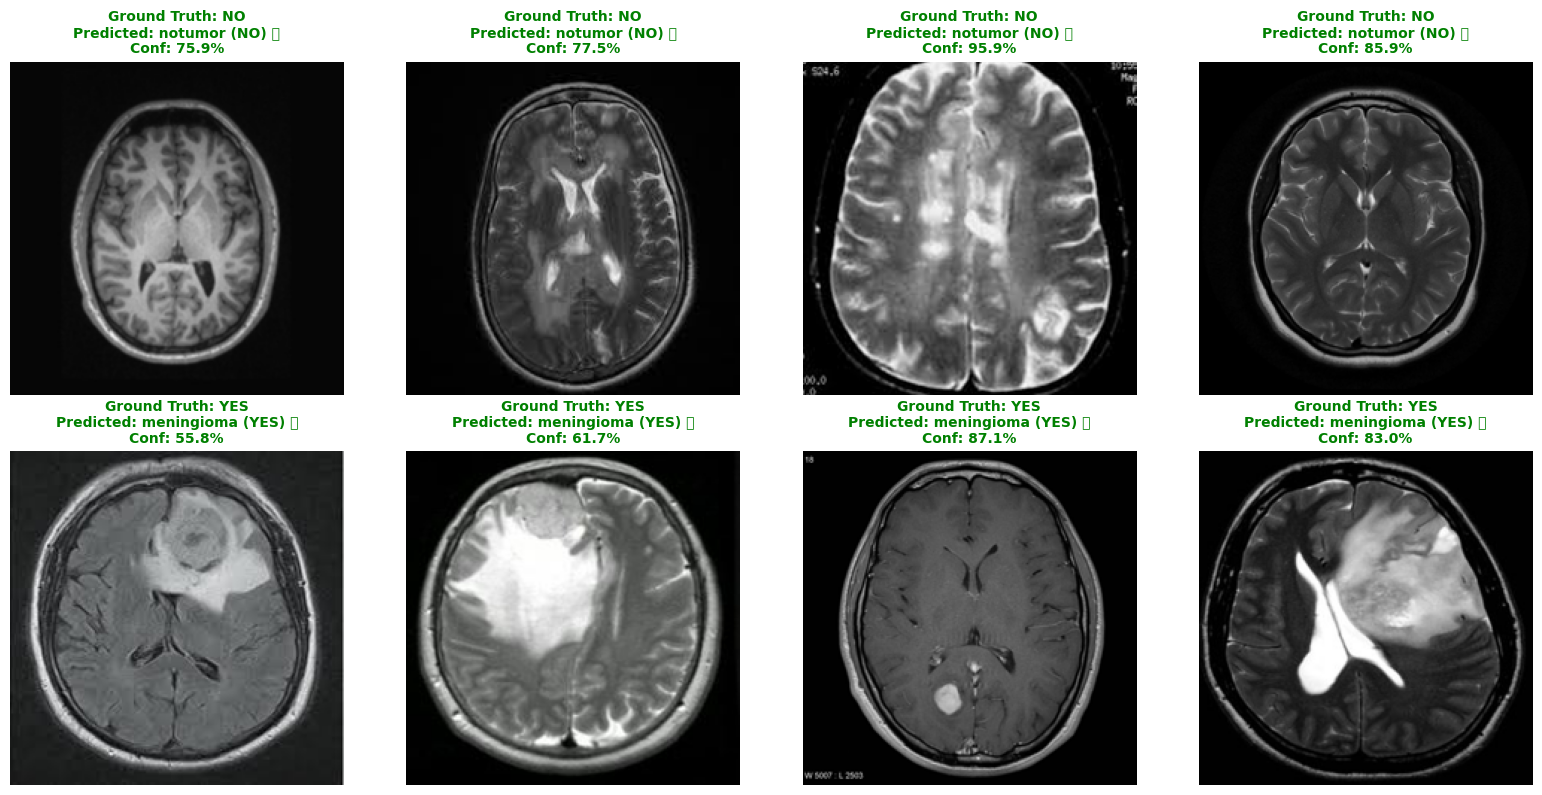

TTA Test Batch Accuracy: 8/8 (100.00%)


In [2]:
import os
import random
import glob
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "/kaggle/working/brain_tumor_resnet50.pt"

# Locate dataset
possible_dataset_paths = [
    "/kaggle/input/brain-mri-images-for-brain-tumor-detection",
    "/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset",
    "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"
]

NEW_DATASET_DIR = next((p for p in possible_dataset_paths if os.path.exists(p)), None)
if NEW_DATASET_DIR is None:
    raise FileNotFoundError("Could not locate binary dataset in /kaggle/input/.")

# Load Model
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
train_classes = checkpoint.get('class_names', ['glioma', 'meningioma', 'notumor', 'pituitary'])

model = models.resnet50(weights=None)
model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.fc.in_features, len(train_classes)))
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_image_files(base_dir, folder_name):
    patterns = [
        os.path.join(base_dir, folder_name, "*.[jJ][pP][gG]"),
        os.path.join(base_dir, folder_name, "*.[jJ][pP][eE][gG]"),
        os.path.join(base_dir, folder_name, "*.[pP][nN][gG]"),
        os.path.join(base_dir, "*", folder_name, "*.[jJ][pP][gG]"),
        os.path.join(base_dir, "*", folder_name, "*.[jJ][pP][eE][gG]"),
        os.path.join(base_dir, "*", folder_name, "*.[pP][nN][gG]")
    ]
    files = []
    for pattern in patterns:
        files.extend(glob.glob(pattern))
    return sorted(list(set(files)))

no_images = get_image_files(NEW_DATASET_DIR, "no")
yes_images = get_image_files(NEW_DATASET_DIR, "yes")

SAMPLES_PER_CLASS = 4
random.seed(42)
sampled_no = random.sample(no_images, min(SAMPLES_PER_CLASS, len(no_images)))
sampled_yes = random.sample(yes_images, min(SAMPLES_PER_CLASS, len(yes_images)))
test_samples = [(p, "no") for p in sampled_no] + [(p, "yes") for p in sampled_yes]

# ----- Test-Time Augmentation (TTA) Prediction -----
def predict_with_tta(pil_img, model):
    img_orig = eval_transform(pil_img).unsqueeze(0).to(device)
    img_hflip = eval_transform(pil_img.transpose(Image.FLIP_LEFT_RIGHT)).unsqueeze(0).to(device)
    img_vflip = eval_transform(pil_img.transpose(Image.FLIP_TOP_BOTTOM)).unsqueeze(0).to(device)

    with torch.no_grad():
        out1 = torch.softmax(model(img_orig), dim=1)
        out2 = torch.softmax(model(img_hflip), dim=1)
        out3 = torch.softmax(model(img_vflip), dim=1)

    avg_probs = ((out1 + out2 + out3) / 3.0)[0].cpu().numpy()
    return avg_probs

plt.figure(figsize=(16, 8))
correct_count = 0

for idx, (img_path, true_label) in enumerate(test_samples):
    pil_img = Image.open(img_path).convert('RGB')
    probs = predict_with_tta(pil_img, model)

    pred_class_idx = int(np.argmax(probs))
    pred_class_name = train_classes[pred_class_idx]
    confidence = float(probs[pred_class_idx] * 100)

    binary_pred = "no" if pred_class_name == "notumor" else "yes"
    is_correct = (binary_pred == true_label)
    if is_correct:
        correct_count += 1

    ax = plt.subplot(2, SAMPLES_PER_CLASS, idx + 1)
    ax.imshow(pil_img.resize((224, 224)))

    status_symbol = "✅" if is_correct else "❌"
    color = "green" if is_correct else "red"

    title_text = (
        f"Ground Truth: {true_label.upper()}\n"
        f"Predicted: {pred_class_name} ({binary_pred.upper()}) {status_symbol}\n"
        f"Conf: {confidence:.1f}%"
    )

    ax.set_title(title_text, fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

accuracy = (correct_count / len(test_samples)) * 100
print("=" * 60)
print(f"TTA Test Batch Accuracy: {correct_count}/{len(test_samples)} ({accuracy:.2f}%)")
print("=" * 60)